# 01. Exploratory Data Analysis & Data Splitting

This notebook focuses on understanding the State Farm Distracted Driver Detection dataset and splitting it into Training and Validation sets based on `subject_id` to prevent data leakage.

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

# Set paths
DATA_DIR = '../data/raw/statefarm'
CSV_PATH = os.path.join(DATA_DIR, 'driver_imgs_list.csv')
IMG_DIR = os.path.join(DATA_DIR, 'imgs/train')

print(f"Reading data from: {CSV_PATH}")

Reading data from: ../data/raw/statefarm/driver_imgs_list.csv


## 1. Load Data

In [19]:
df = pd.read_csv(CSV_PATH)
print(f"Total images: {len(df)}")
df.head()

Total images: 22424


,subject,classname,img
0,p002,c0,img_44733.jpg
1,p002,c0,img_72999.jpg
2,p002,c0,img_25094.jpg
3,p002,c0,img_69092.jpg
4,p002,c0,img_92629.jpg


## 2. EDA - Class Distribution

The 10 classes are:
- **c0**: normal driving
- **c1**: texting - right
- **c2**: talking on the phone - right
- **c3**: texting - left
- **c4**: talking on the phone - left
- **c5**: operating the radio
- **c6**: drinking
- **c7**: reaching behind
- **c8**: hair and makeup
- **c9**: talking to passenger

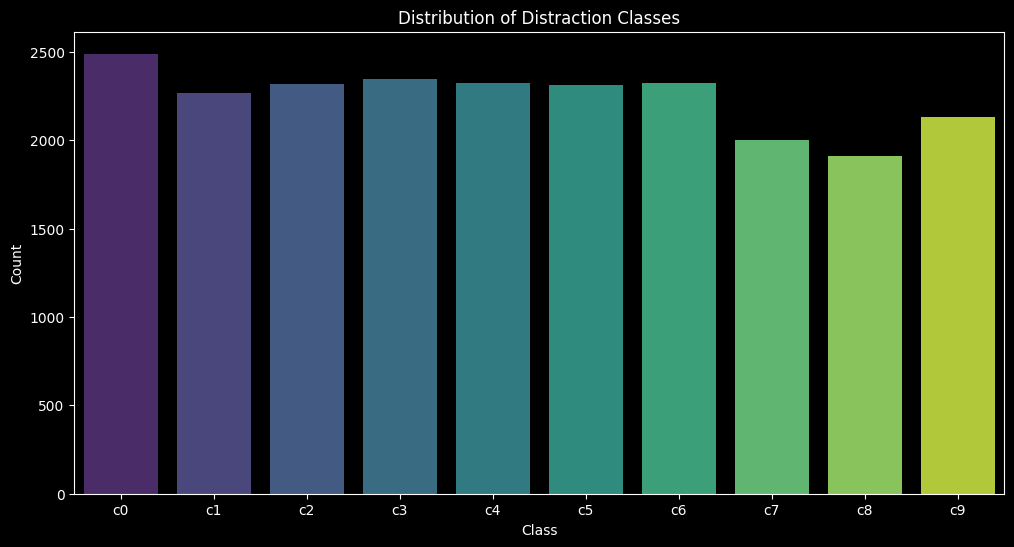

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='classname', hue='classname', palette='viridis', legend=False)
plt.title('Distribution of Distraction Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## 3. EDA - Drivers (Subjects)

It's crucial to see how many images we have per driver.

Total unique drivers: 26


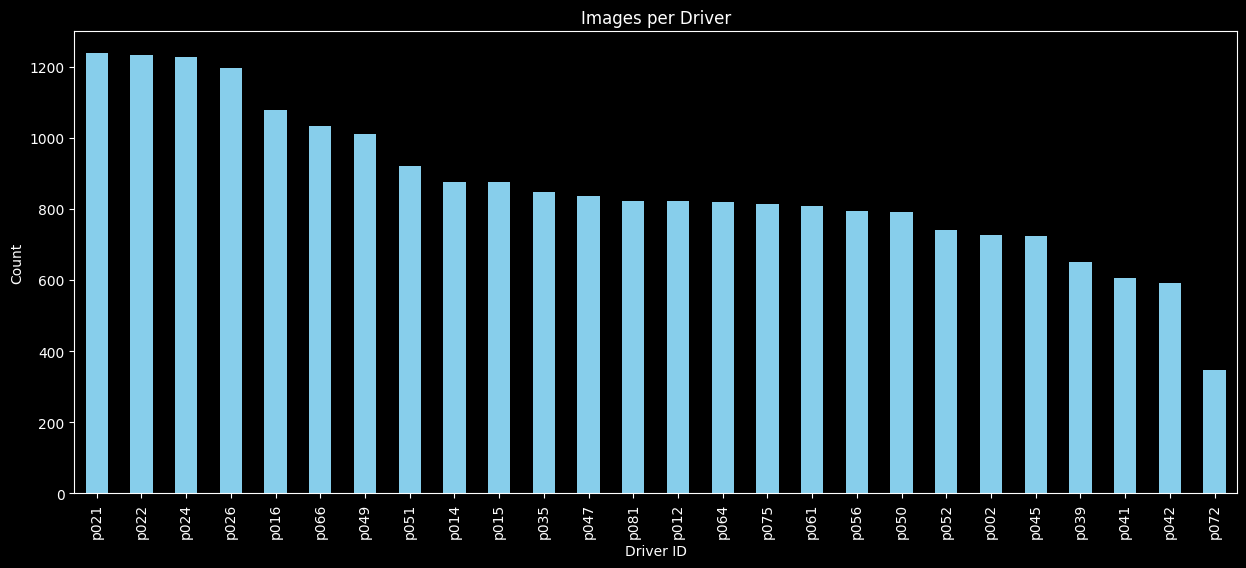

In [21]:
driver_counts = df['subject'].value_counts()
print(f"Total unique drivers: {len(driver_counts)}")

plt.figure(figsize=(15, 6))
driver_counts.plot(kind='bar', color='skyblue')
plt.title('Images per Driver')
plt.xlabel('Driver ID')
plt.ylabel('Count')
plt.show()

## 4. Group Splitting

To ensure the model generalizes to new people, we split by `subject` (ID tài xế).

In [22]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)

for train_idx, val_idx in gss.split(df, groups=df['subject']):
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

print(f"Training set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")

train_drivers = train_df['subject'].unique()
val_drivers = val_df['subject'].unique()

print(f"Training drivers: {len(train_drivers)}")
print(f"Validation drivers: {len(val_drivers)}")
print(f"Overlap: {set(train_drivers).intersection(set(val_drivers))}") # Should be empty

Training set: 18899 images
Validation set: 3525 images
Training drivers: 22
Validation drivers: 4
Overlap: set()


## 5. View Sample Images

In [23]:
import cv2

def show_images_per_class(df, img_dir, n=3):
    classes = sorted(df['classname'].unique())
    fig, axes = plt.subplots(len(classes), n, figsize=(15, 25))
    
    for i, cls in enumerate(classes):
        subset = df[df['classname'] == cls].sample(n)
        for j, (_, row) in enumerate(subset.iterrows()):
            img_path = os.path.join(img_dir, cls, row['img'])
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{cls} - {row['subject']}")
            axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()

# show_images_per_class(train_df, IMG_DIR) # Uncomment to see samples

## 6. Save Splitted Metadata

We will save these dataframes to use them in the training notebook.

In [24]:
OUTPUT_DIR = '../data/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_df.to_csv(os.path.join(OUTPUT_DIR, 'train_metadata.csv'), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, 'val_metadata.csv'), index=False)

print("Metadata saved to data/processed/")

Metadata saved to data/processed/
